In [1]:
import pandas as pd

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
kagglehub.__version__

'0.3.13'

In [4]:
import os

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sb

In [7]:
import numpy as np

In [8]:
dataset_path = kagglehub.dataset_download("gauthamp10/google-playstore-apps")

In [9]:
print("Dataset files:", os.listdir(dataset_path))

Dataset files: ['Google-Playstore.csv']


In [10]:
csv_path = os.path.join(dataset_path, "Google-Playstore.csv")

In [11]:
try:
    df = pd.read_csv(csv_path, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding='latin1')

In [12]:
df.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           object 
 1   App Id             object 
 2   Category           object 
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           object 
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           object 
 11  Size               object 
 12  Minimum Android    object 
 13  Developer Id       object 
 14  Developer Website  object 
 15  Developer Email    object 
 16  Released           object 
 17  Last Updated       object 
 18  Content Rating     object 
 19  Privacy Policy     object 
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       object 
dtypes: bool(4), float64(4), int64(1), object(15)
memor

In [14]:
df.columns

Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time'],
      dtype='object')

Our dataset contains Application data of more than 600K applications with the following 23 attributes:

- App Name, App Id, Category, Rating, Rating Count,Installs, Minimum Installs, Maximum Installs, Free, Price, Currency, Size, Minimum Android, Developer Id,Developer Website, Developer Email, Released, Privacy Policy, Last Updated ,Content Rating, Ad Supported, In app purchases, Editor Choice

- The focus will be to find out what attribrutes affect the ratings of the applications.

Some Questions to be explored include:
- Do larger or more expensive apps receive higher or lower ratings?

- Are free apps generally rated better or worse than paid apps?

- Which categories consistently achieve high ratings (e.g., Education vs Games)?

- Do apps with more installs tend to have better or worse ratings? (Sometimes very popular apps may get lower ratings due to higher expectations.)

- Do developers with multiple apps have generally better ratings (experience advantage)?

- Do apps offering in-app purchases receive higher ratings (perhaps due to richer features) or lower ones (due to perceived greed)?

Data cleaning - Remove duplicates, make sure each column has the correct data type

In [15]:
df = df.drop_duplicates(subset=['App Id'], keep='first')

In [16]:
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

In [17]:
df['Installs'] = df['Installs'].replace('[+,]', '', regex=True).astype(float)

In [18]:
def clean_size(x):
    if isinstance (x, str):
        x = x.strip().replace(',', '')  # remove commas
        x = x.upper()     
        if 'M' in x:
            return float(x.replace('M', ''))
        elif 'K' in x:
            return float(x.replace('K', '')) / 1024
        elif 'G' in x:
            return float(x.replace('G','')) * 1024
        
        else:
            return None
    return None
df['Size_MB'] = df['Size'].apply(clean_size)    


In [19]:
df['Released'] = pd.to_datetime(df['Released'], errors='coerce')

In [20]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

In [21]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [22]:
df['Days_Since_Last_Update'] = (pd.Timestamp.now() - df['Last Updated']).dt.days

In [23]:
df.isnull().sum().sort_values(ascending=False)

Developer Website         760835
Privacy Policy            420953
Size_MB                    74973
Released                   71053
Rating Count               22883
Rating                     22883
Minimum Android             6530
Size                         196
Currency                     135
Installs                     107
Minimum Installs             107
Developer Id                  33
Developer Email               31
App Name                       5
App Id                         0
Free                           0
Maximum Installs               0
Category                       0
Price                          0
Last Updated                   0
Ad Supported                   0
Content Rating                 0
In App Purchases               0
Editors Choice                 0
Scraped Time                   0
Days_Since_Last_Update         0
dtype: int64

In [28]:
df = df.dropna(subset=['Rating'])

In [24]:
df.isnull().sum().sort_values(ascending=False).head(10)

Developer Website    760835
Privacy Policy       420953
Size_MB               74973
Released              71053
Rating Count          22883
Rating                22883
Minimum Android        6530
Size                    196
Currency                135
Installs                107
dtype: int64

Out of the 600K+ apps, 22,883 did not have a rating. 3.81%. These have been dropped because the focus is on ratings.

**UNIVARIATE ANALYSIS**

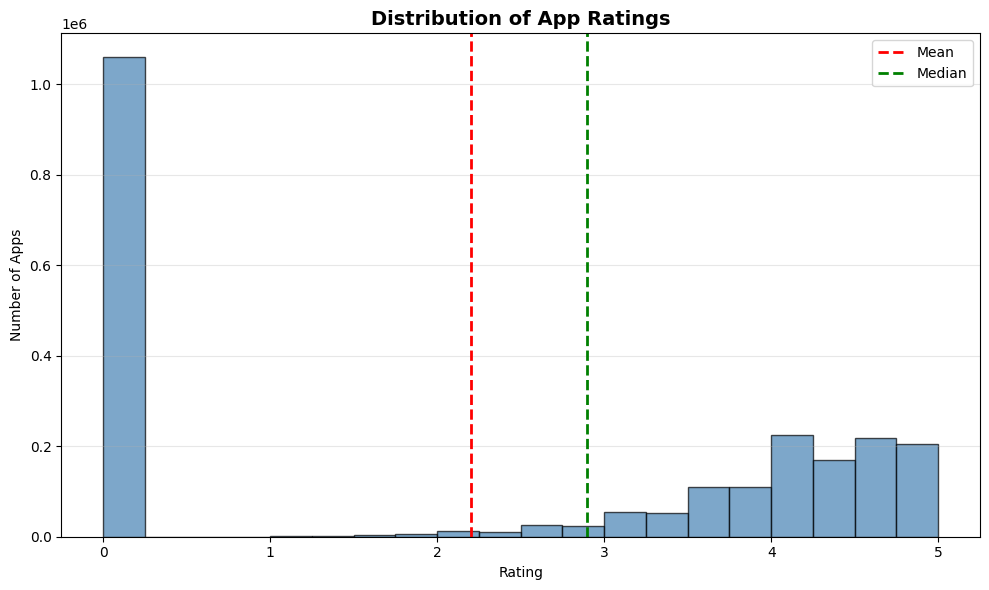

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(df['Rating'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.axvline(df['Rating'].median(), color='green', linestyle='--', linewidth=2, label='Median')
plt.title('Distribution of App Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
pd.set_option('display.float_format', '{:.2f}'.format)
print(df['Rating'].describe())

count   2290061.00
mean          2.20
std           2.11
min           0.00
25%           0.00
50%           2.90
75%           4.30
max           5.00
Name: Rating, dtype: float64


From the histogram above, I have found that good number of the apps have a 0 rating, yet when rating 0 is not a value it should be from 1 to 5. I will clean that up so that we can use a data set with valid ratings and then answer or questions wwith clarity

In [27]:
zero_rating = df[df['Rating']==0]
print("Number of apps with zero ratings:", len(zero_rating))

Number of apps with zero ratings: 1059762


In [28]:
df_valid = df[(df['Rating'] >= 1) & (df['Rating'] <= 5)]

In [29]:
df_valid['Rating'].count()

np.int64(1230299)

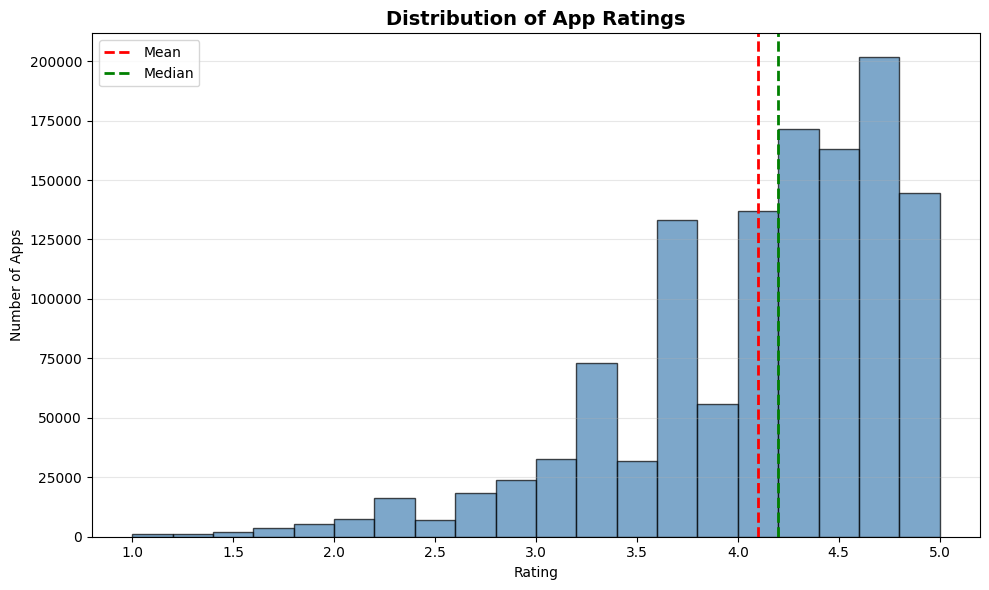

count   1230299.00
mean          4.10
std           0.69
min           1.00
25%           3.80
50%           4.20
75%           4.60
max           5.00
Name: Rating, dtype: float64


In [30]:
plt.figure(figsize=(10, 6))
plt.hist(df_valid['Rating'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(df_valid['Rating'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.axvline(df_valid['Rating'].median(), color='green', linestyle='--', linewidth=2, label='Median')
plt.title('Distribution of App Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(df_valid['Rating'].describe())

In [31]:
highest_rating = df_valid[df_valid['Rating']>=4]
print(len(highest_rating))

817653


Most of the apps from the cleaned out dataset are rated 4 and 5.🙌

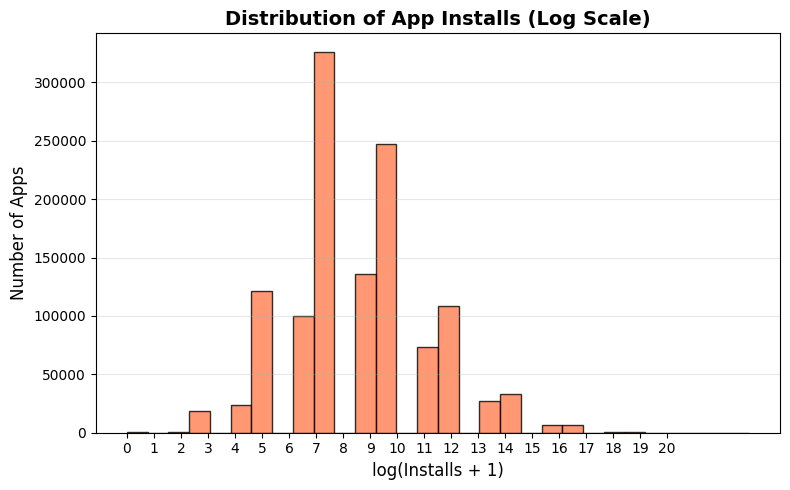

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df_valid['Installs']), bins=30, edgecolor='black', color='coral', alpha=0.8)
plt.title('Distribution of App Installs (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('log(Installs + 1)', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(np.arange(0, 21, 1))
plt.tight_layout()
plt.show()

The histogram is heavily right-skewed (more concentrated on the lower log values).
- The tallest peaks (log 7–10) correspond to apps with roughly 1,000–20,000 installs, meaning most apps never go viral and attract modest user bases.
- A noticeable cluster extends up to log 12–13 (≈100K–500K installs) — these are well-performing but not dominant apps.
- Beyond log 15, only a tiny fraction of apps exist — those are the top global performers

In [33]:
df_valid['Installs'].describe()

count       1230299.00
mean         344025.27
std        20745085.37
min               0.00
25%            1000.00
50%            5000.00
75%           10000.00
max     10000000000.00
Name: Installs, dtype: float64

In [34]:
df_valid['Category'].nunique()

48

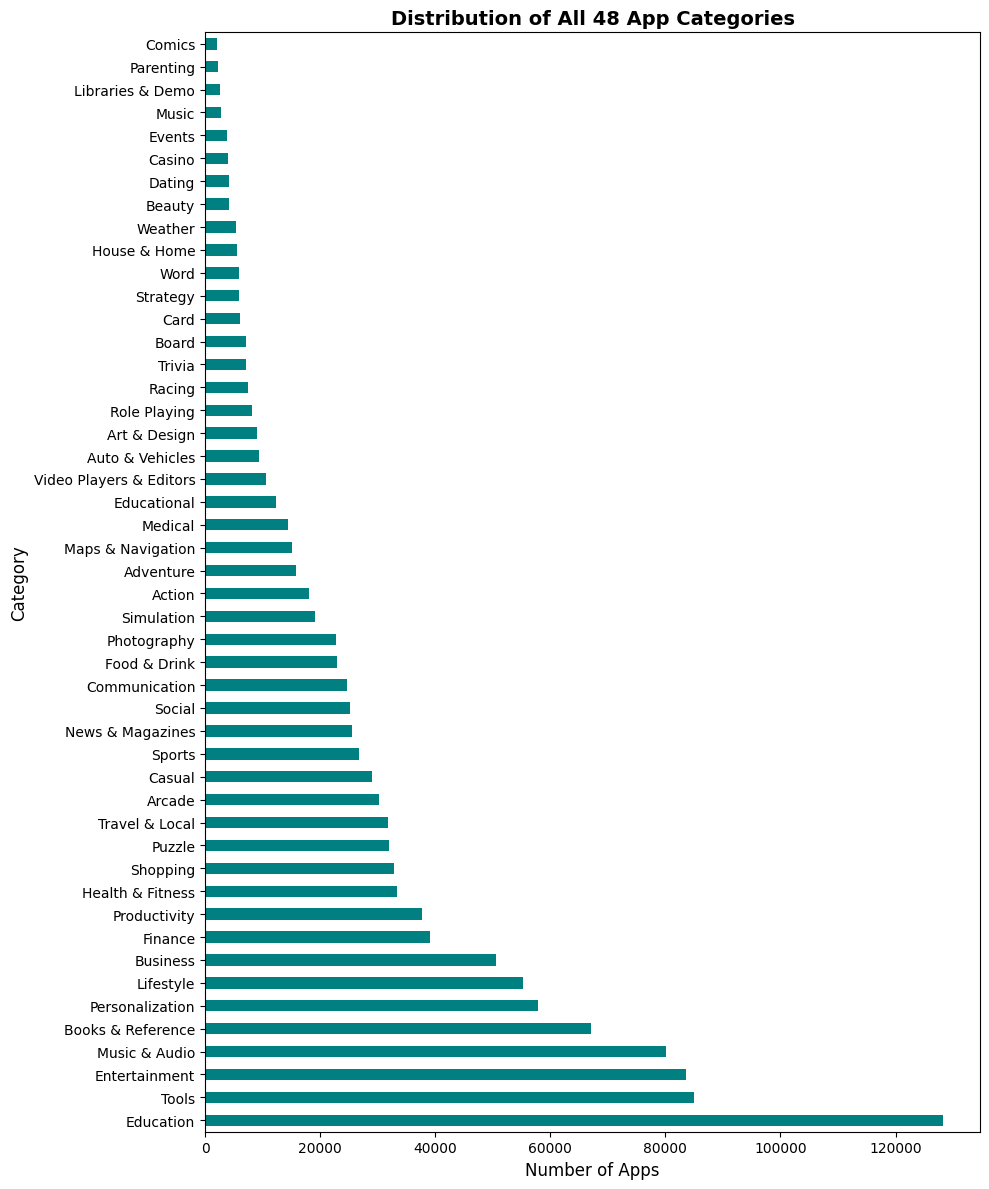

Total categories: 48

Category distribution statistics:
count       48.00
mean     25631.23
std      26849.33
min       2057.00
25%       6113.00
50%      16923.00
75%      32157.75
max     128258.00
Name: count, dtype: float64


In [35]:
fig, ax = plt.subplots(figsize=(10, 12))
category_counts = df_valid['Category'].value_counts()
category_counts.plot(kind='barh', color='teal', ax=ax)
plt.title('Distribution of All 48 App Categories', fontsize=14, fontweight='bold')
plt.xlabel('Number of Apps', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total categories: {len(category_counts)}")
print(f"\nCategory distribution statistics:")
print(category_counts.describe())

- The graph above shows the distribution of the apps' categories.
- We have 48 unique categories 
- Most of the apps are educational - 128258 apps.
- The least number of apps are Comical apps - 2057

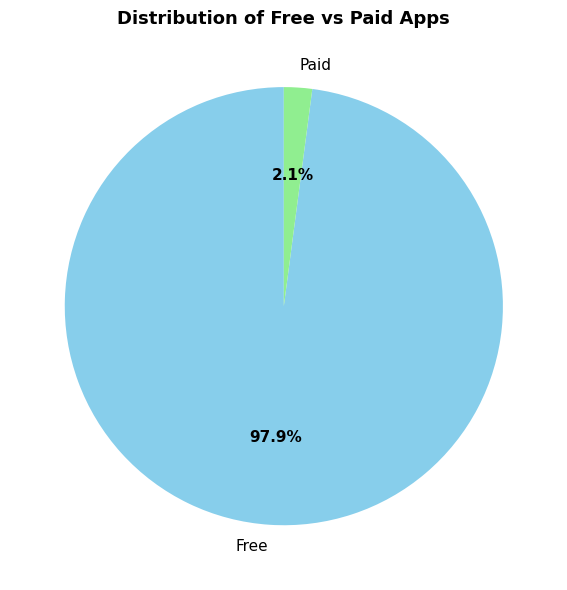

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
counts = df_valid['Free'].value_counts()
labels = ['Free', 'Paid']
colors = ['skyblue', 'lightgreen']
wedges, texts, autotexts = ax.pie(counts.values, labels=labels, autopct='%1.1f%%', 
                                    colors=colors, startangle=90, textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
ax.set_title('Distribution of Free vs Paid Apps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
df_valid['Content Rating'].value_counts().head(10)

Content Rating
Everyone           1062357
Teen                109298
Mature 17+           36505
Everyone 10+         21930
Unrated                125
Adults only 18+         84
Name: count, dtype: int64

In [38]:
df_valid['Content Rating'].unique()

array(['Everyone', 'Teen', 'Mature 17+', 'Everyone 10+',
       'Adults only 18+', 'Unrated'], dtype=object)

- The distribution of the content ratings are as below. Most apps can be used by everyone.
- Those restricted to adults only and the unrated ones are very litte hence they do not appear clearly in the chart

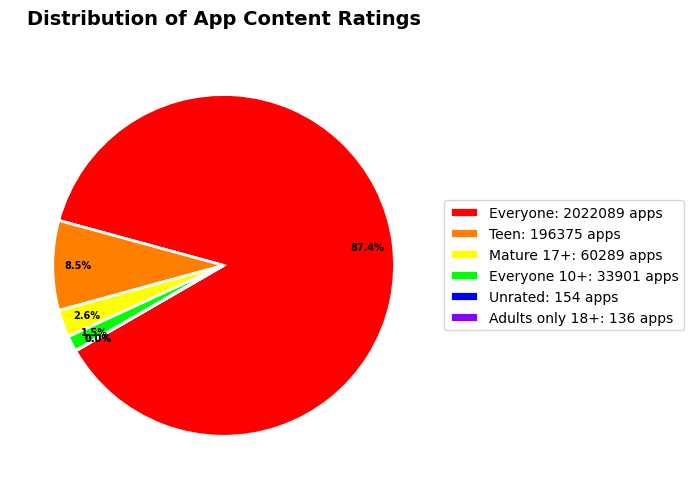

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
ratings = df['Content Rating'].value_counts()
colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#0000FF', '#8B00FF']
wedges, texts, autotexts = ax.pie(
    ratings.values,
    #labels=ratings.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=210,
    #textprops={'fontsize':7, 'weight': 'bold'},
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(7)
ax.set_title('Distribution of App Content Ratings', fontsize=14, fontweight='bold', pad=20)
legend_labels = [f'{rating}: {count} apps' for rating, count in ratings.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

plt.tight_layout()
plt.show()

**BIVARIATE ANALYSIS**

In [40]:
df_valid.columns

Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time', 'Size_MB', 'Days_Since_Last_Update'],
      dtype='object')

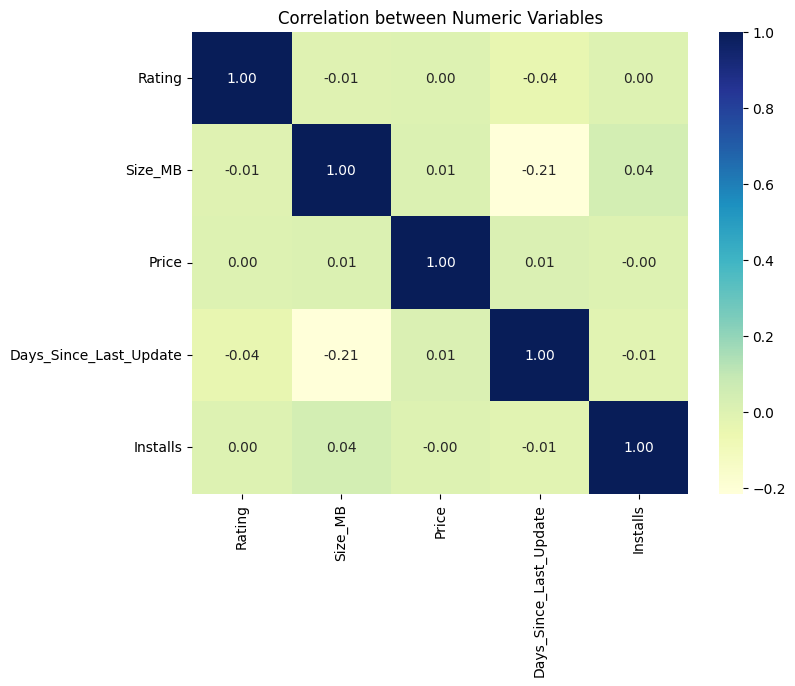

In [41]:
num_cols = ['Rating', 'Size_MB', 'Price', 'Days_Since_Last_Update', 'Installs']
plt.figure(figsize=(8,6))
sb.heatmap(df_valid[num_cols].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation between Numeric Variables')
plt.show()

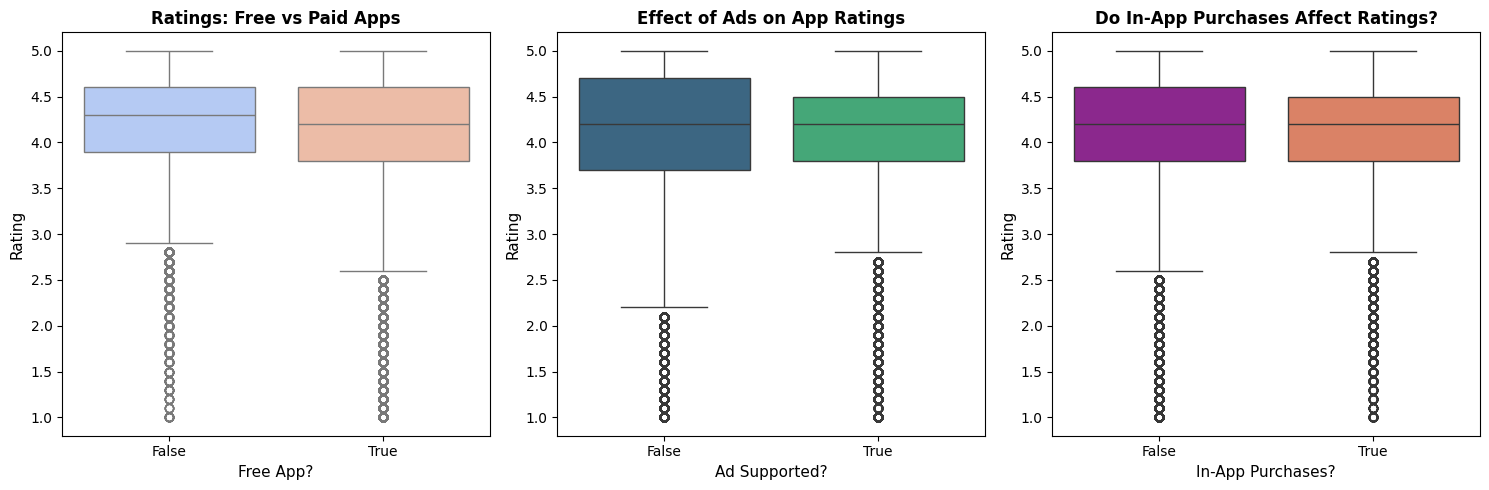

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sb.boxplot(data=df_valid, x='Free', y='Rating', hue='Free', palette='coolwarm', ax=axes[0], legend=False)
axes[0].set_title('Ratings: Free vs Paid Apps', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Free App?', fontsize=11)
axes[0].set_ylabel('Rating', fontsize=11)

sb.boxplot(data=df_valid, x='Ad Supported', y='Rating', hue='Ad Supported', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Effect of Ads on App Ratings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ad Supported?', fontsize=11)
axes[1].set_ylabel('Rating', fontsize=11)

sb.boxplot(data=df_valid, x='In App Purchases', y='Rating', hue='In App Purchases', palette='plasma', ax=axes[2], legend=False)
axes[2].set_title('Do In-App Purchases Affect Ratings?', fontsize=12, fontweight='bold')
axes[2].set_xlabel('In-App Purchases?', fontsize=11)
axes[2].set_ylabel('Rating', fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\Awendi Joy\AppData\Local\Temp\ipykernel_9964\2179778211.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


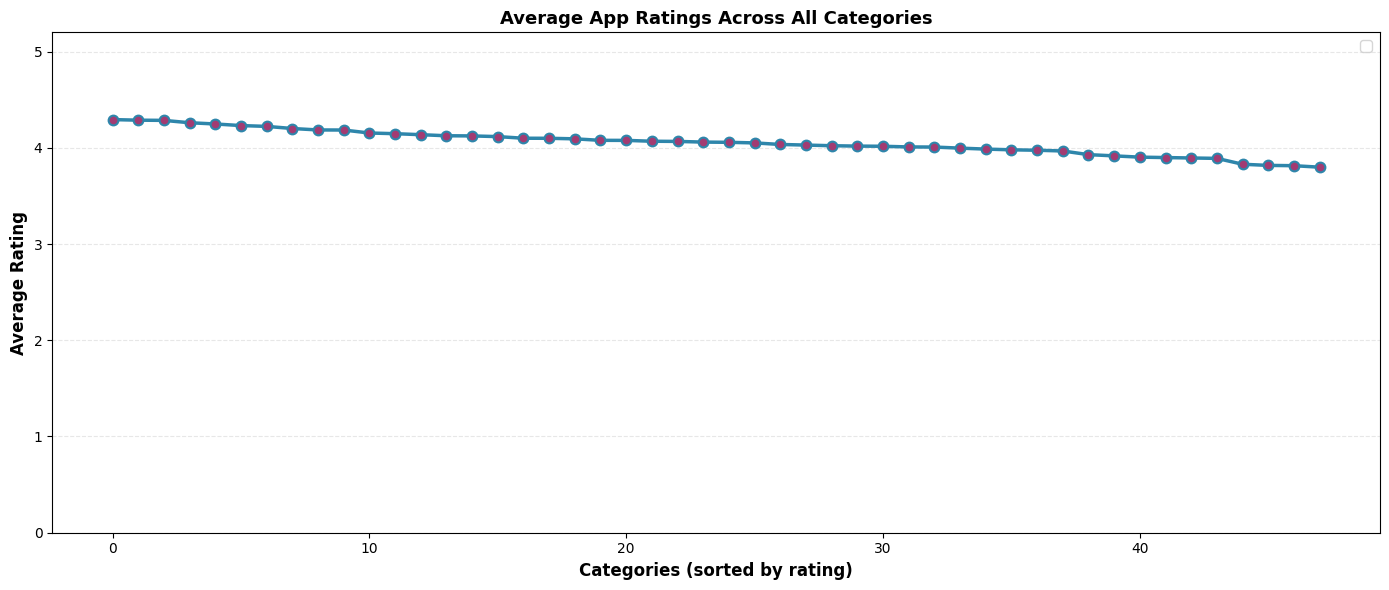

In [43]:
cat_ratings = df_valid.groupby('Category')['Rating'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(cat_ratings)), cat_ratings.values, marker='o', linewidth=2.5, 
        markersize=7, color='#2E86AB', markerfacecolor='#A23B72', markeredgewidth=1.5, 
        markeredgecolor='#2E86AB')
ax.set_xlabel('Categories (sorted by rating)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Rating', fontsize=12, fontweight='bold')
ax.set_title('Average App Ratings Across All Categories', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
ax.set_ylim(0, 5.2)

plt.tight_layout()
plt.show()

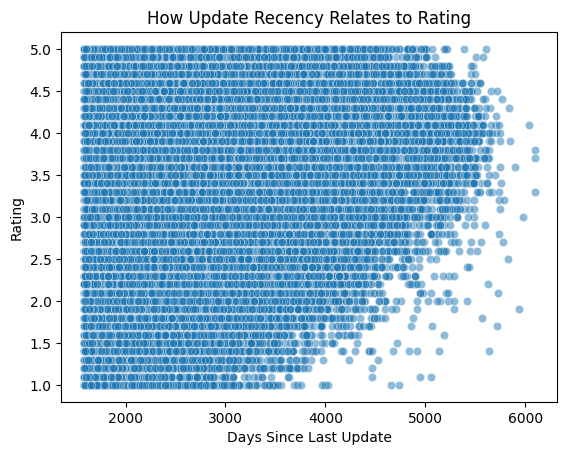

In [44]:
sb.scatterplot(data=df_valid, x='Days_Since_Last_Update', y='Rating', alpha=0.5)
plt.title('How Update Recency Relates to Rating')
plt.xlabel('Days Since Last Update')
plt.ylabel('Rating')
plt.show()

In [45]:
df_valid['Days_Since_Last_Update'].describe()

count   1230299.00
mean       2156.69
std         605.58
min        1583.00
25%        1696.00
50%        1951.00
75%        2411.00
max        6093.00
Name: Days_Since_Last_Update, dtype: float64

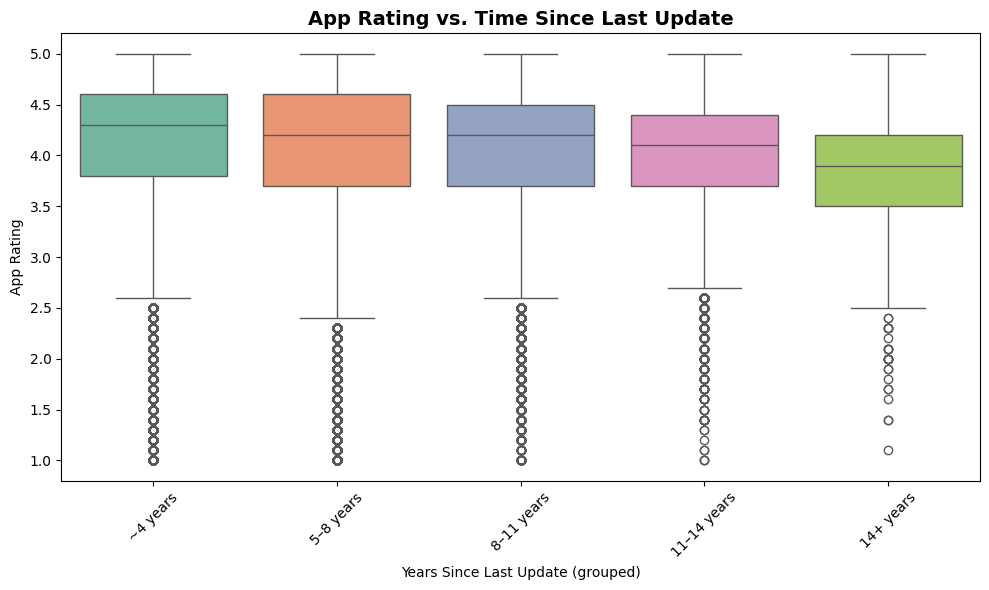

In [46]:
bins = [1500, 2000, 3000, 4000, 5000, 6100]
labels = ['~4 years', '5–8 years', '8–11 years', '11–14 years', '14+ years']
df_valid = df_valid.copy()
df_valid['Days_Bin'] = pd.cut(df_valid['Days_Since_Last_Update'], bins=bins, labels=labels, include_lowest=True)
fig, ax = plt.subplots(figsize=(10, 6))
sb.boxplot(data=df_valid, x='Days_Bin', y='Rating', hue='Days_Bin', palette='Set2', legend=False, ax=ax)
ax.set_title('App Rating vs. Time Since Last Update', fontsize=14, fontweight='bold')
ax.set_xlabel('Years Since Last Update (grouped)')
ax.set_ylabel('App Rating')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [59]:
df_valid['Installs'].describe()

count       1230299.00
mean         344025.27
std        20745085.37
min               0.00
25%            1000.00
50%            5000.00
75%           10000.00
max     10000000000.00
Name: Installs, dtype: float64

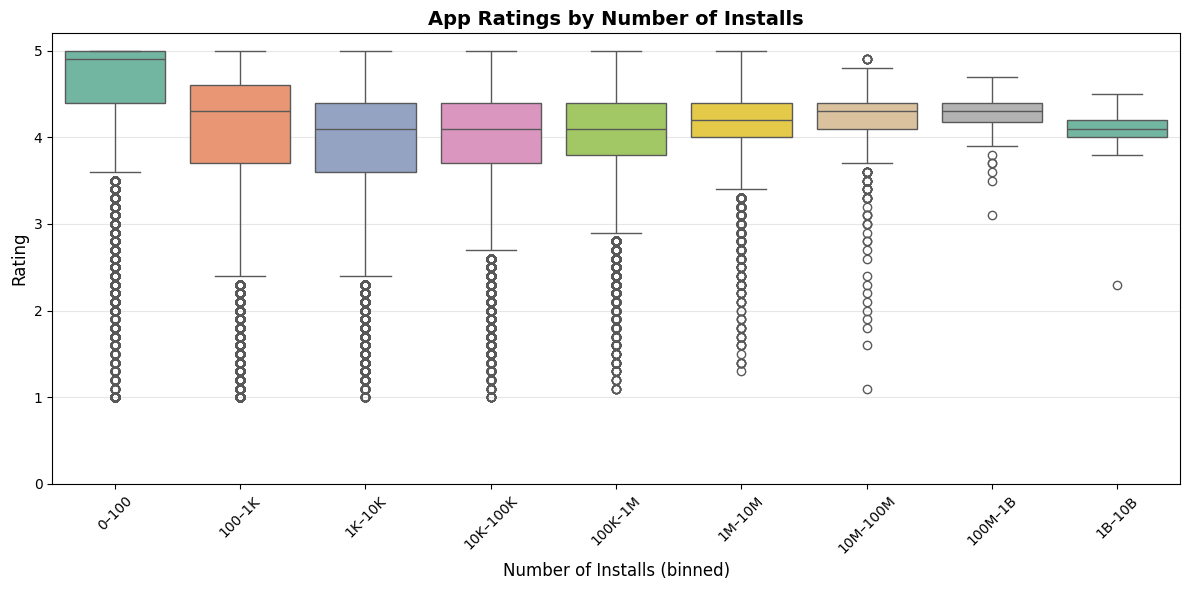

In [47]:
df_valid = df_valid.copy()
bins = [0, 100, 1000, 10000, 100000, 1_000_000, 10_000_000,
        100_000_000, 1_000_000_000, 10_000_000_000]
labels = ['0–100', '100–1K', '1K–10K', '10K–100K', '100K–1M',
          '1M–10M', '10M–100M', '100M–1B', '1B–10B']
df_valid['Installs_Bin'] = pd.cut(df_valid['Installs'], bins=bins, labels=labels, include_lowest=True)
plt.figure(figsize=(12, 6))
sb.boxplot(data=df_valid, x='Installs_Bin', y='Rating', hue='Installs_Bin', palette='Set2', legend=False)
plt.title('App Ratings by Number of Installs', fontsize=14, fontweight='bold')
plt.xlabel('Number of Installs (binned)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 5.2)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
df_valid.columns

Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time', 'Size_MB', 'Days_Since_Last_Update', 'Days_Bin',
       'Installs_Bin'],
      dtype='object')

**MULTIVARIATE ANALYSIS**

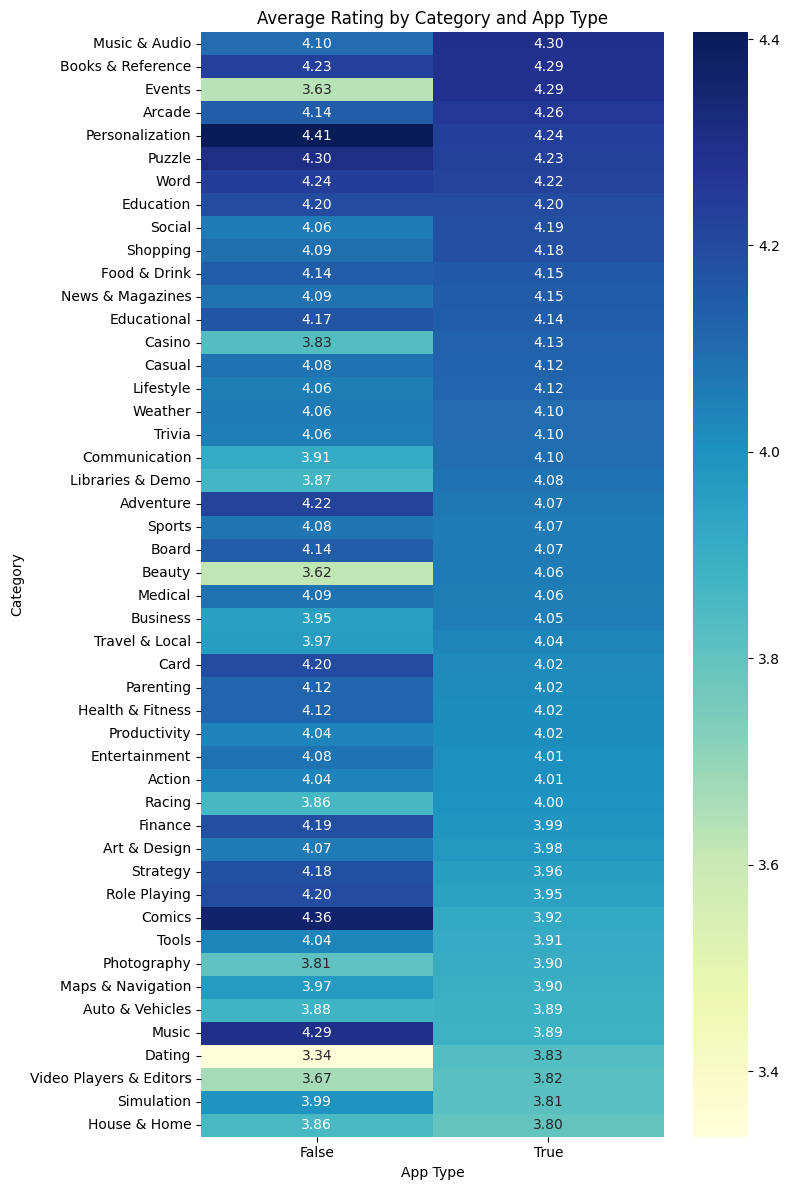

In [48]:
#rating_summary = (df_valid.groupby(['Category', 'Free'])['Rating'].mean().unstack().sort_values(by='True', ascending=False))
rating_summary = (df_valid.groupby(['Category', 'Free'])['Rating'].mean().unstack().sort_values(by=True, ascending=False))

plt.figure(figsize=(8, 12))
sb.heatmap(rating_summary, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Average Rating by Category and App Type')
plt.xlabel('App Type')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

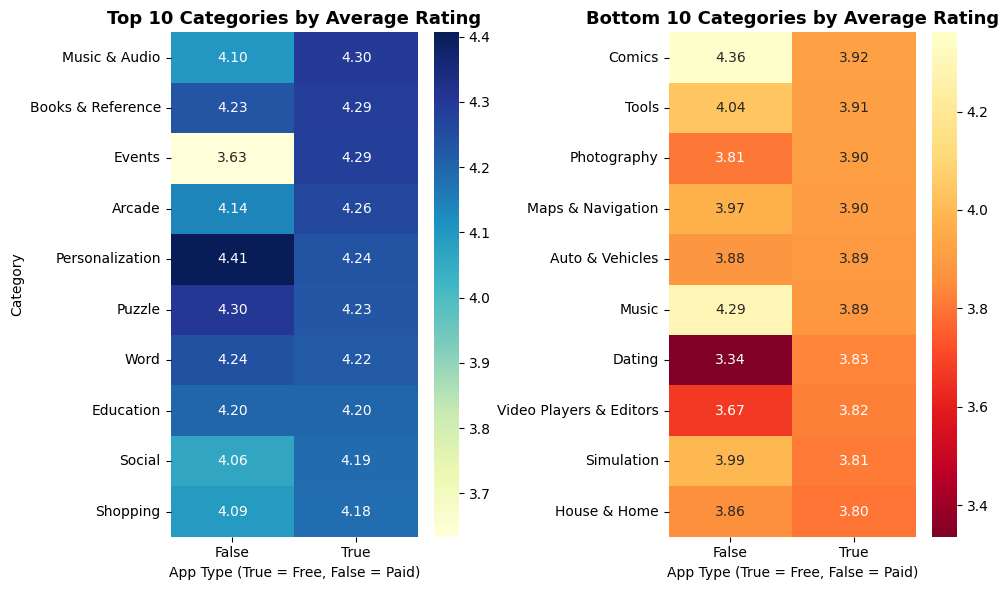

In [49]:
rating_summary = (
    df_valid.groupby(['Category', 'Free'])['Rating']
    .mean()
    .unstack()
)

# --- Step 2: Sort by Free app average rating ---
rating_summary_sorted = rating_summary.sort_values(by=True, ascending=False)

# --- Step 3: Split into Top 10 and Bottom 10 categories ---
top10 = rating_summary_sorted.head(10)
bottom10 = rating_summary_sorted.tail(10)

# --- Step 4: Create the side-by-side heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Top 10 Heatmap
sb.heatmap(top10, annot=True, cmap='YlGnBu', fmt=".2f", ax=axes[0])
axes[0].set_title('Top 10 Categories by Average Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('App Type (True = Free, False = Paid)')
axes[0].set_ylabel('Category')

# Bottom 10 Heatmap
sb.heatmap(bottom10, annot=True, cmap='YlOrRd_r', fmt=".2f", ax=axes[1])
axes[1].set_title('Bottom 10 Categories by Average Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('App Type (True = Free, False = Paid)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

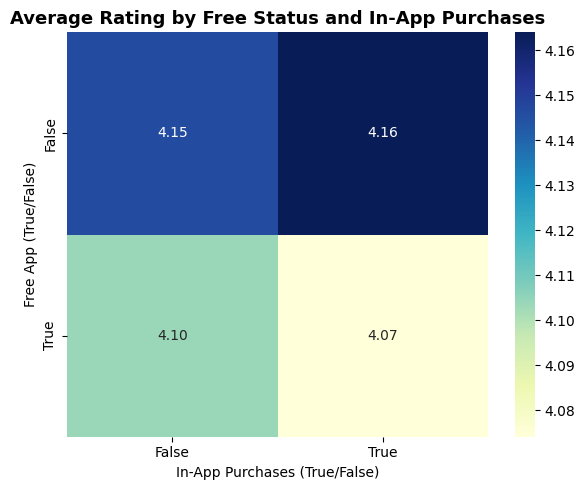

In [53]:
# Group by Free and In App Purchases
iap_heatmap = (df_valid.groupby(['Free', 'In App Purchases'])['Rating'].mean().unstack())

# Plot the heatmap
plt.figure(figsize=(6, 5))
sb.heatmap(iap_heatmap, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Average Rating by Free Status and In-App Purchases', fontsize=13, fontweight='bold')
plt.xlabel('In-App Purchases (True/False)')
plt.ylabel('Free App (True/False)')
plt.tight_layout()
plt.show()

C:\Users\Awendi Joy\AppData\Local\Temp\ipykernel_9964\3218042471.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Awendi Joy\OneDrive\Documents\Py Data\stone\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


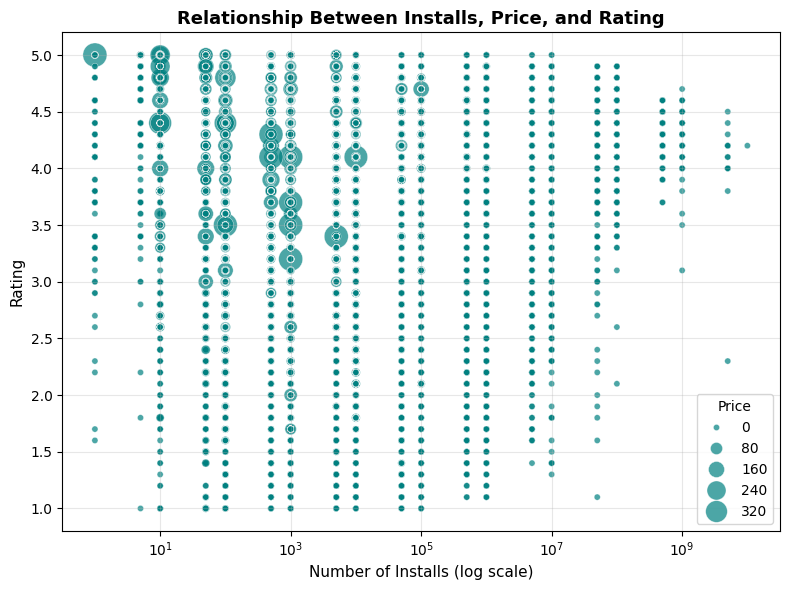

In [57]:
plt.figure(figsize=(8, 6))

# Scatter plot: Installs (x), Rating (y), Price (size)
sb.scatterplot(
    data=df_valid,
    x='Installs',
    y='Rating',
    size='Price',          # Bubble size now represents price
    alpha=0.7,
    color='teal',          # Calm single tone for clarity
    sizes=(20, 300)
)

# Log scale for Installs to handle large range
plt.xscale('log')

# Titles and labels
plt.title('Relationship Between Installs, Price, and Rating', fontsize=13, fontweight='bold')
plt.xlabel('Number of Installs (log scale)', fontsize=11)
plt.ylabel('Rating', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()